# Tarea semanal 6 (filtros digitales)

In [2]:
#import y definiciones usadas
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig

def myBodePlot(w, h):
    plt.figure(figsize=(12, 6))
    plt.subplot(2,1,1)
    plt.plot(w, 20 * np.log10(np.abs(h)))
    plt.grid()
    plt.xlabel(f"frecuencia normalizada")
    plt.ylabel("Ganancia [dB]")

    plt.subplot(2,1,2)
    plt.plot(w, np.angle(h))
    plt.grid()
    plt.xlabel(f"frecuencia normalizada")
    plt.ylabel("Fase [rad]")

    plt.show()

def plotTimeSignal(t, signals, labels):
    #len(signal) == len(labels) me olvido de la verificacion
    for i in range(len(signals)):
        plt.plot(t, signals[i], label=labels[i])
    plt.grid()
    plt.legend()
    plt.xlabel('tiempo')
    plt.ylabel('amplitud')
    plt.tight_layout()

## PUNTO 1

El sistema esta compuesto por dos bloques en cascada por lo tanto la transferencia me queda de la siguiente manera:

$$H(z) = H_{comb}(z) \cdot H_{biquad}(z)$$

Para el caso del comb.

$$W(z) = X(z) - C_1Z^{-N}X(z) \Rightarrow \boxed{H_{comb}(z) = \frac{w(z)}{x(z)} = 1 - c_1Z^{-N}}$$

Para el caso del biquad.

$$a_0 (w(z) b_0 + w(z)b_1 Z^{-1} + w(z)b_2Z^{-2}) = y(z) - a_1y(z)Z^{-1} - a_2 y(z)Z^{-2}$$

$$w(z)(b_0 + b_1 Z^{-1} + b_2 Z^{-2}) = \frac{1}{a_0}Y(z)(1 - a_1 Z^{-1} - a_2 Z^{-2})$$

$$H_{biquad}(z) = \frac{Y(z)}{W(z)} = \frac{b_0 + b_1 Z^{-1} + b_2 Z^{-2}}{1/a_0 - a_1/a_0 Z^{-1} - a_2/a_0 Z^{-2}}$$

$$\boxed{H_{biquad}(z) = \frac{b_0 + b_1 Z^{-1} + b_2 Z^{-2}}{1/a_0 - a_1 Z^{-1} - a_2 Z^{-2}}}$$

Combinando ambos:

$$\boxed{H(z) = H_{comb}(z) \cdot H_{biquad}(z) = (1 - c_1Z^{-N} ) \cdot \frac{b_0 + b_1 Z^{-1} + b_2 Z^{-2}}{1/a_0 - a_1 Z^{-1} - a_2 Z^{-2}}}$$

## Filtro de Media movil (CIC)

$$H[z] = \frac{\frac{1}{N} - \frac{1}{N} \cdot Z^{-N}}{1 - Z^{-1}}$$

Para el caso de N=3

$$H[z] = \frac{\frac{1}{3}(1 - Z^{-3})}{1 - Z^{-1}}$$
$$b = [1/3,\ 0,\ 0,-1/3] \qquad a = [1, -1]$$

Es un filtro IIR debido a que el denominado no es igual a 1.

Un filtro FIR de media movil se la puede calcula de la siguiente manera:

$$ y[n] =  \frac{1}{N} \cdot \sum x[n-i] \qquad que\ va\ de \ i=0 \ a\ N-1$$

$$H[z] = \frac{1}{N} \cdot \sum Z^{-i}$$

para el caso de N=3

$$H(z) = \frac{1}{3}(1 + Z^{-1} + Z^{-2})$$

---

Tanto si se lo implementa como FIR o IIR ambas tienen la misma respuesta en frecuencia, es decir, son matematicamente equivalentes.

La principal ventaja que se puede obtener en la implementacion con el IIR es computacionalmente mucho mas eficiente debido a que no importa el N siempre sera una suma y una resta. En cambio con el FIR la ventaja que se obtiene es estable y tiene una fase lineal.

Las desventajas que se pueden detallar son que si se implementa con el IIR se necesitaria una precision mas grande, en cambio con el FIR su costo computacional crece con el N.

Si se quisiera implementar una media movil con un N pequeño es mejor un FIR debido a su estabilidad, en cambio para N grandes la implementacion con IIR es mas eficiente.

---

$$h(k) = (1, 1, 1, 1, 1, 1, 1)$$

Si se podria implementar esta topologia con el CIC debido a que esto lo podemos visualizar con un FIR de media movil con N = 7.

$$H(z) = 1 + z^{-1} + z^{-2} + z^{-3} + z^{-4} + z^{-5} + z^{-6}$$

Si lo implementaramos como un IIR con N=7

$$H(z) = \frac{1 - Z^{-7}}{1 - Z^{-1}}$$

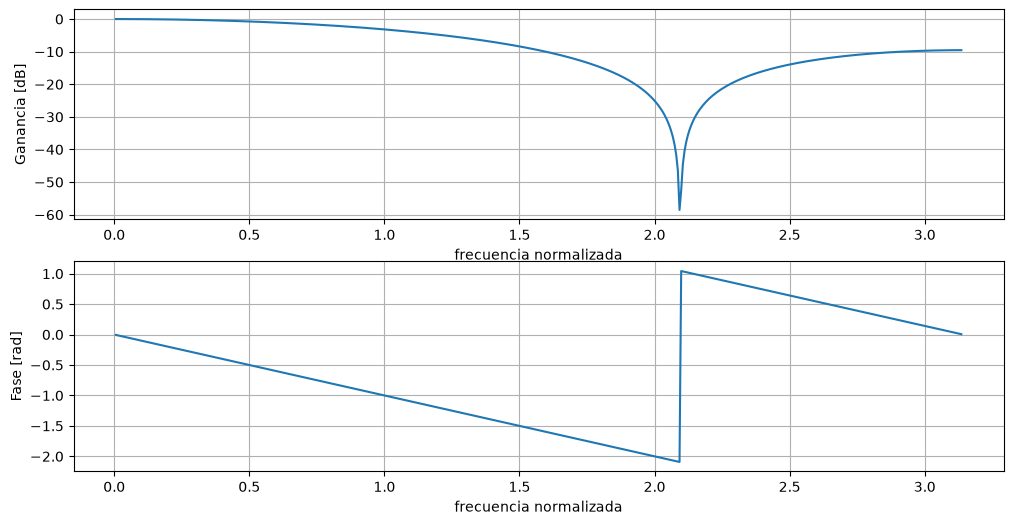

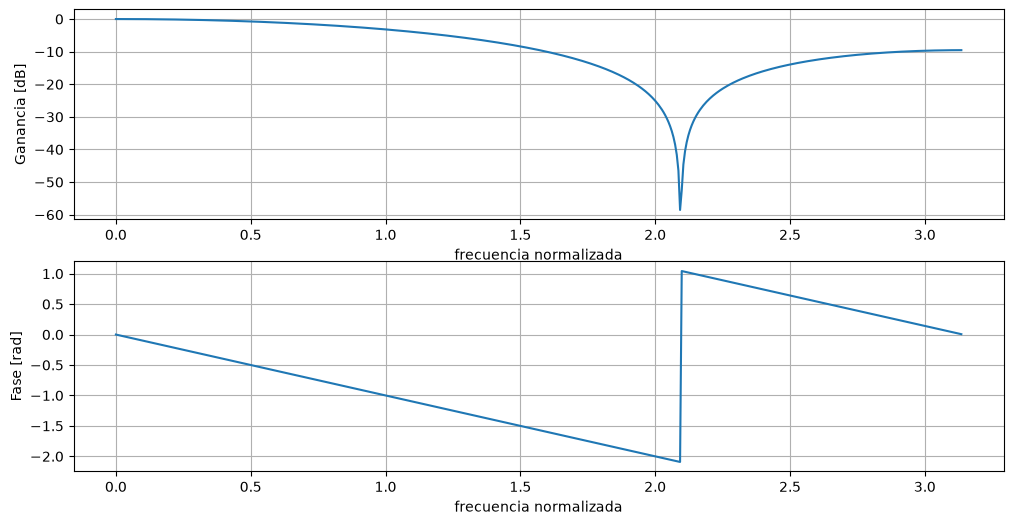

In [58]:
N1 = 3
N2 = 4
N3 = 5

num1 = [1/N1] + [0]*(N1-1) + [-1/N1]
den = [1, -1]

num2 = [1/N2] + [0]*(N2-1) + [-1/N2]   #N=4
num3 = [1/N3] + [0]*(N3-1) + [-1/N3]   #N=5

w1, h1 = sig.freqz(num1, den)
w2, h2 = sig.freqz(num2, den)
w3, h3 = sig.freqz(num3, den)

#VISUALIZACION en frecuencia
myBodePlot(w1,h1)

#Implementacion fir de media 3
numfir = [1/N1,1/N1,1/N1]
denfir = [1]

wfir, hfir = sig.freqz(numfir, denfir)
myBodePlot(wfir, hfir)

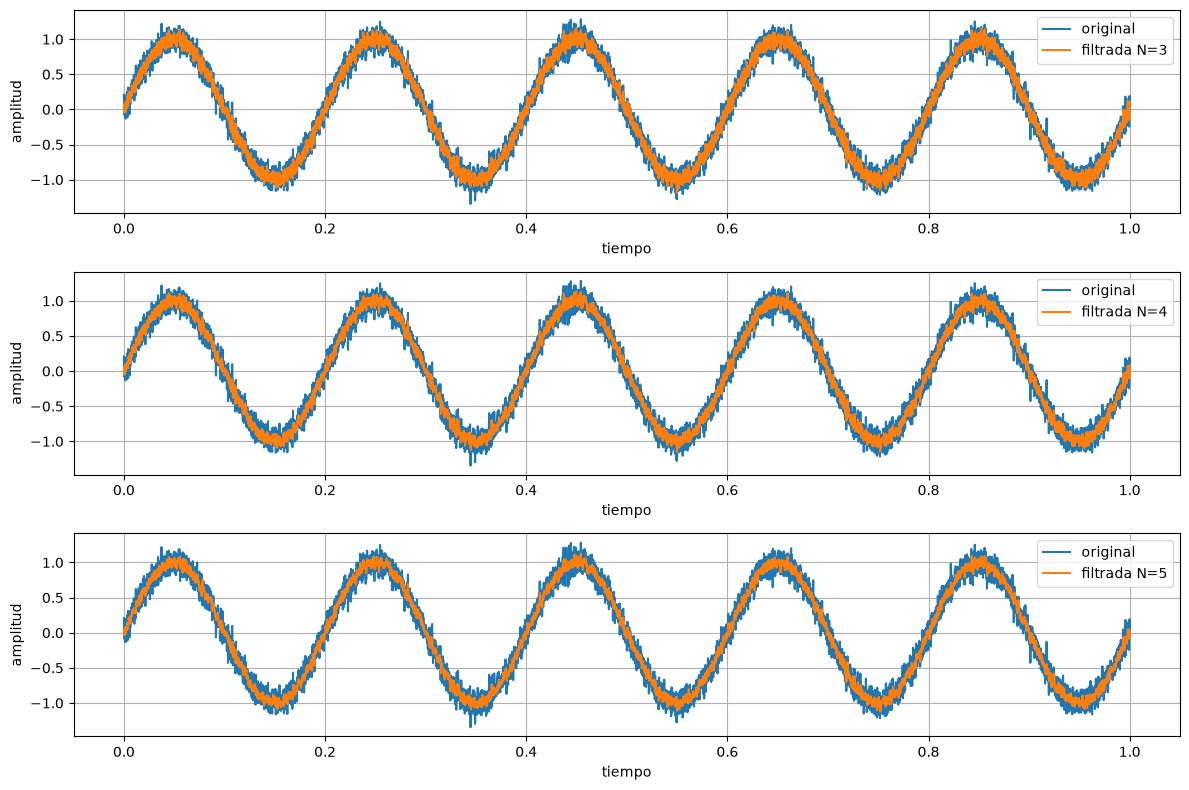

In [59]:
#aplicacion a seno discreto
fs = 8000
f_sin = 5
t = np.linspace(0, 1, fs)
Vpp = 1
# se le agrega un ruido para poder visualizar la media movil
x = Vpp*np.sin(2*np.pi*t*f_sin) + np.random.normal(0, 0.1*Vpp, fs)

#aplico el filtro
y1 = sig.lfilter(num1, den, x)
y2 = sig.lfilter(num2, den, x)
y3 = sig.lfilter(num3, den, x)


plt.figure(figsize=(12,8))
plt.subplot(3,1,1)
plotTimeSignal(t, (x, y1), ("original", "filtrada N=3"))
plt.subplot(3,1,2)
plotTimeSignal(t, (x, y2), ("original", "filtrada N=4"))
plt.subplot(3,1,3)
plotTimeSignal(t, (x, y3), ("original", "filtrada N=5"))

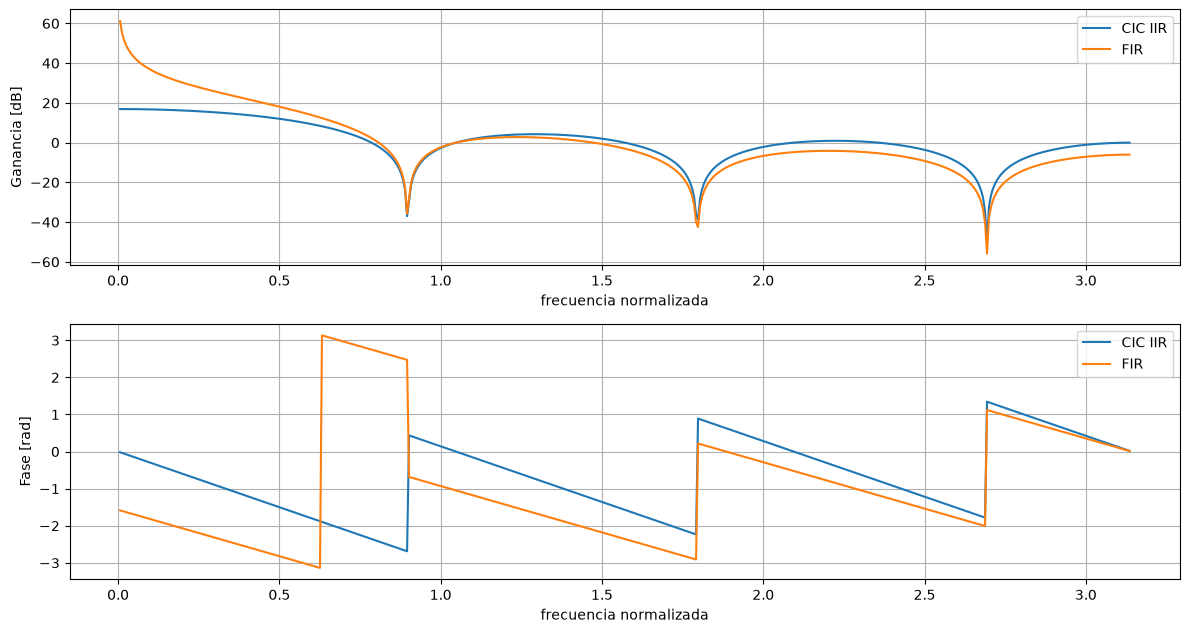

In [66]:
N = 7
numx = [1] + [0]*(N-1) + [-1]
denx = [1, -1]
numx2 = [1]*N

wx, hx = sig.freqz(numx, denx)
wx2, hx2 = sig.freqz(numx2, denx)

plt.figure(figsize=(12, 6))
plt.subplot(2,1,1)
plt.plot(wx, 20 * np.log10(np.abs(hx)), label="CIC IIR")
plt.plot(wx2, 20 * np.log10(np.abs(hx2)), label="FIR")
plt.grid()
plt.xlabel(f"frecuencia normalizada")
plt.ylabel("Ganancia [dB]")
plt.legend()
plt.tight_layout()

plt.subplot(2,1,2)
plt.plot(wx, np.angle(hx), label="CIC IIR")
plt.plot(wx2, np.angle(hx2), label="FIR")
plt.grid()
plt.xlabel(f"frecuencia normalizada")
plt.ylabel("Fase [rad]")
plt.legend()

plt.show()

## Filtro diferenciador

$$H(z) = 0.5 - 0.5 \cdot Z^{-2}$$


Al aplicar el filtro a un seno discreto y comparar esa salida con la derivada se observa que tiene una similitud muy igual.

C:\Users\brian\AppData\Local\Temp\ipykernel_20696\1397109513.py:9: RuntimeWarning: divide by zero encountered in log10
  plt.plot(w, 20 * np.log10(np.abs(h)))


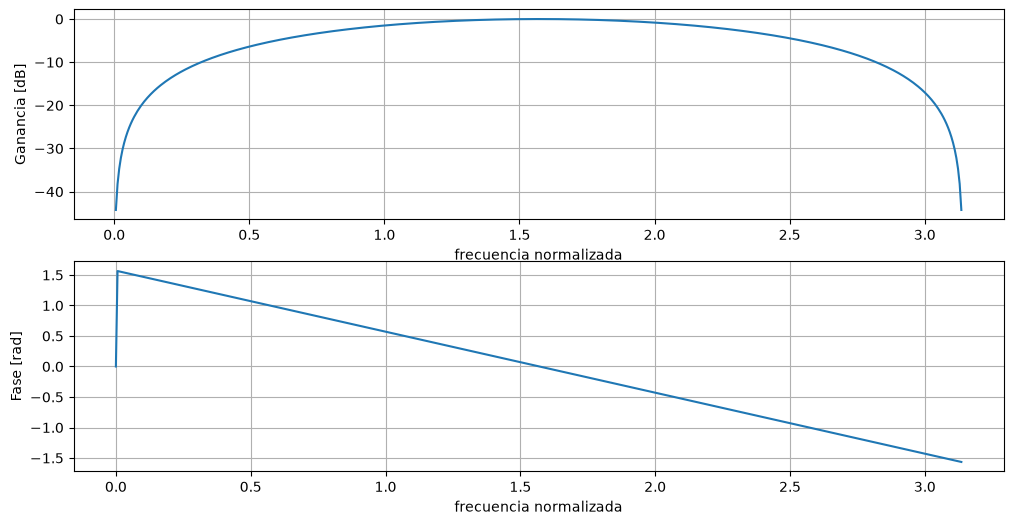

In [23]:
num = [0.5, 0, -0.5]
den = [1]

w ,h = sig.freqz(num, den)

#VISUALIZCION
myBodePlot(w,h)

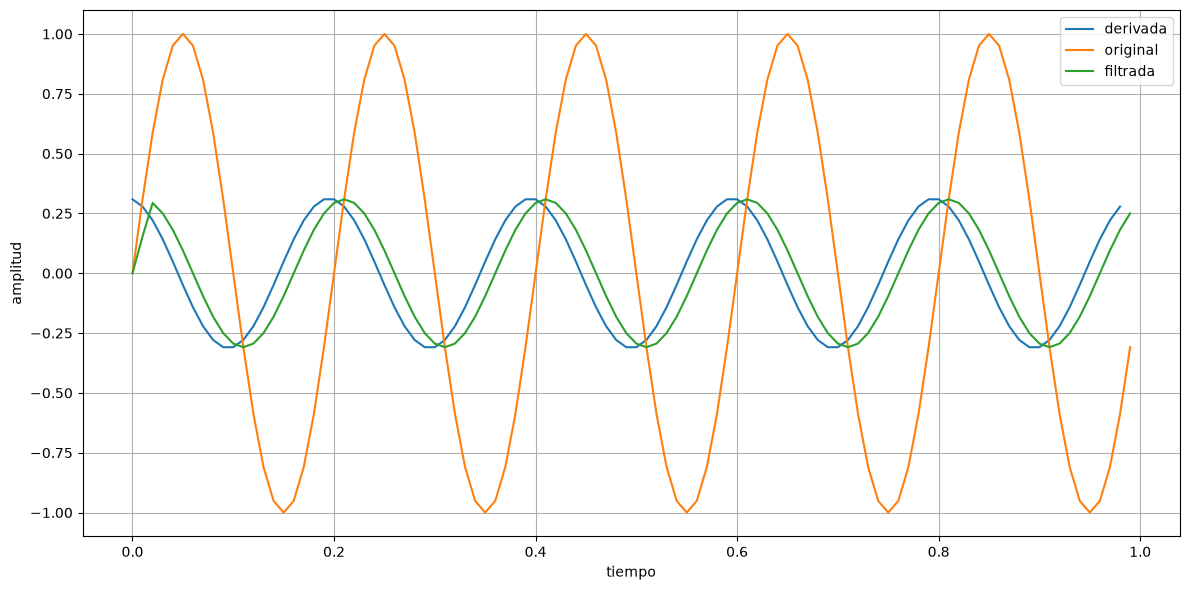

In [33]:
#aplicacion a un seno discreto
fs = 100
f_sin = 5
t = np.arange(0,1,1/fs)
x = np.sin(2*np.pi*t*f_sin)

#aplico el filtro
y = sig.lfilter(num, den, x)
y2 = np.diff(x)

plt.figure(figsize=(12,6))
plt.plot(t[:-1], y2, label="derivada")
plotTimeSignal(t, (x, y), ('original', 'filtrada'))

## Filtro Elimina continua (DC block)

$$H(z) = \frac{1 - Z^{-1}}{1 - \beta \cdot Z^{-1}} \Rightarrow \beta=0.9$$

---

Para poder obtener que en $\beta$ en $\Omega=0.1\pi$ obtenga < $3db \cdot |H(\pi)|$ se lo realiza con python.

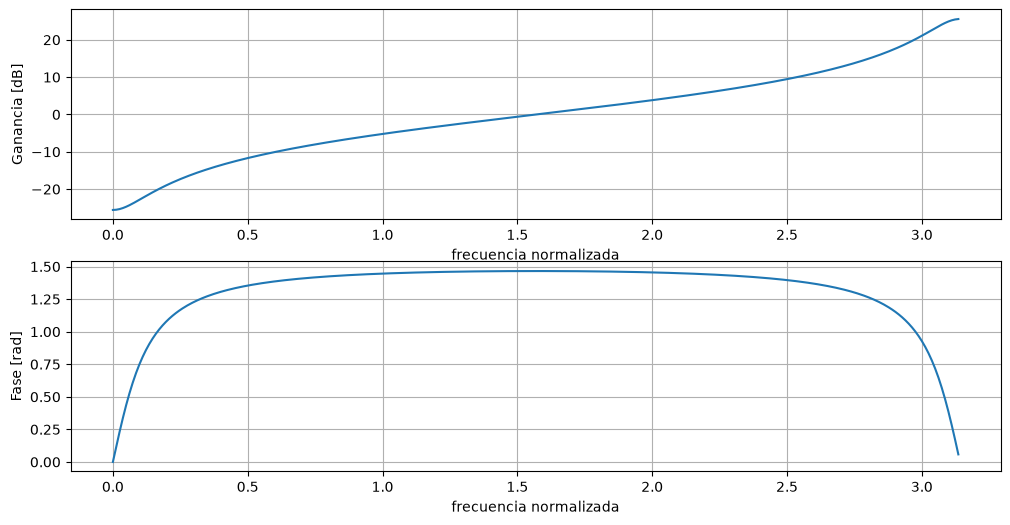

In [81]:
beta = 0.9
num = [1, -beta]
den = [1, beta]

w01, h01 = sig.freqz(num, den)
myBodePlot(w01,h01)

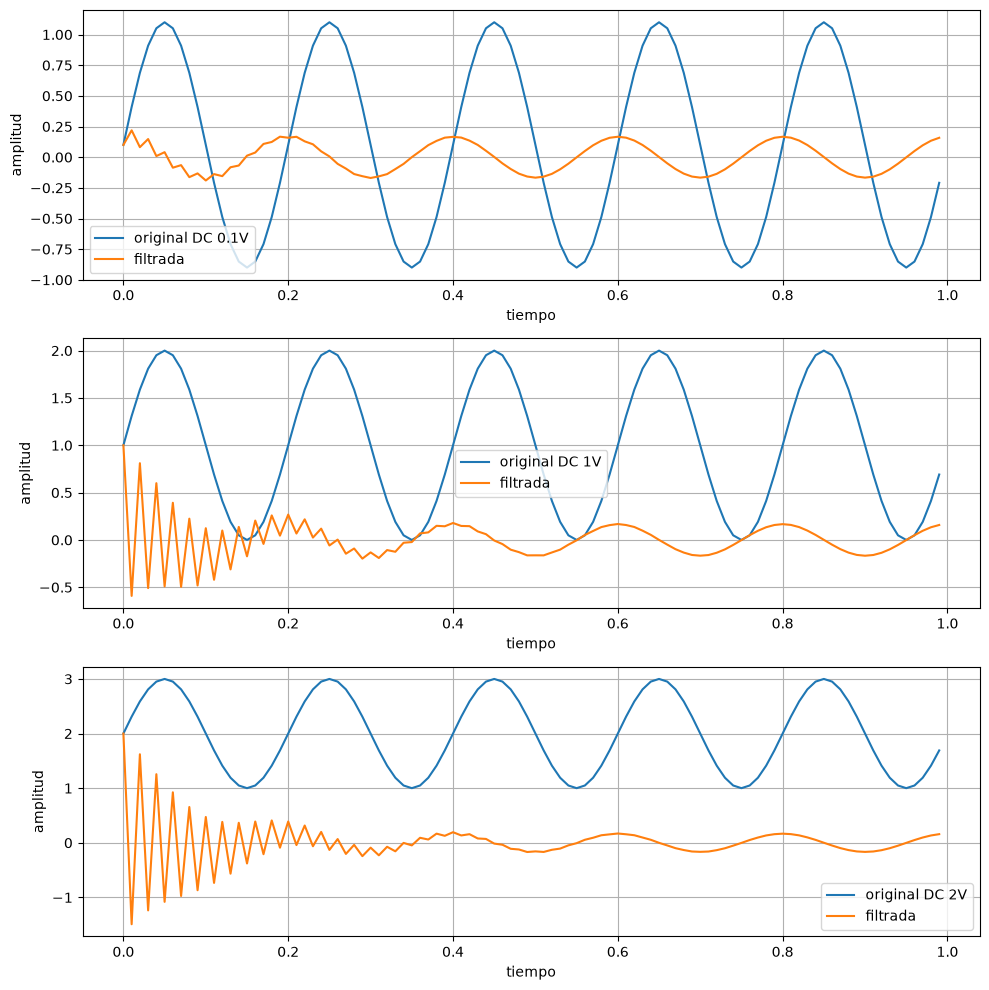

In [70]:
# testeo con un seno discreto

fs = 100
f_sin = 5
DC = 1
t = np.arange(0,1,1/fs)
x = np.sin(2*np.pi*t*f_sin) + 0.1
x1 = np.sin(2*np.pi*t*f_sin) + 1
x2 = np.sin(2*np.pi*t*f_sin) + 2

#filtro
y = sig.lfilter(num,den, x)
y1 = sig.lfilter(num,den, x1)
y2 = sig.lfilter(num,den, x2)

#VISUALIZACION
plt.figure(figsize=(10,10))
plt.subplot(3,1,1)
plotTimeSignal(t, (x,y),("original DC 0.1V", "filtrada"))
plt.subplot(3,1,2)
plotTimeSignal(t, (x1,y1),("original DC 1V", "filtrada"))
plt.subplot(3,1,3)
plotTimeSignal(t, (x2,y2),("original DC 2V", "filtrada"))



0.088


C:\Users\brian\AppData\Local\Temp\ipykernel_20696\2243286563.py:28: RuntimeWarning: divide by zero encountered in log10
  plt.plot(wf, 20 * np.log10(np.abs(hf)), label=f"Beta {beta_bueno}")


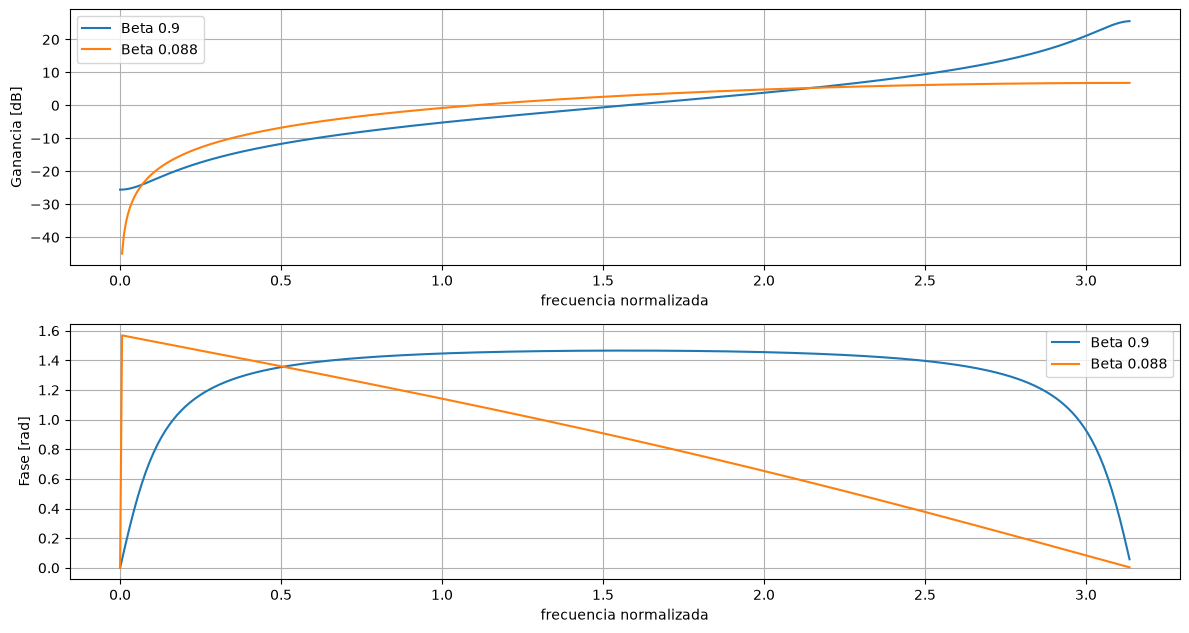

In [82]:
def calcularDiffDb(beta):
    b = [1, -beta]
    a = [1, beta]
    w, h = sig.freqz(b, a, worN=2000) #2000 para mas detalle
    # w va de 0 a pi, con -1 obtengo la magitud de pi y con 0.1 la mag de 0.1*pi
    mag_pi = np.abs(h[-1])
    mag_01pi = np.abs(h[int(len(w) * 0.1)])
    # se calcula la diferencia entre magnitudes
    dif_db = 20*np.log10(mag_01pi / mag_pi)
    return dif_db

betas = np.arange(0,1,1/1000) #1000 valores posibles de beta
res = [calcularDiffDb(b) for b in betas] #diferencias entre 0.1pi y pi

#busco donde se obtiene la menor diferencia
beta_bueno = betas[np.argmin(np.abs(np.array(res)-(-3)))]

print(beta_bueno)

b_final = [1, -1]
a_final = [1, beta_bueno]

wf, hf = sig.freqz(b_final, a_final)

plt.figure(figsize=(12, 6))
plt.subplot(2,1,1)
plt.plot(w01, 20 * np.log10(np.abs(h01)), label=f"Beta {beta}")
plt.plot(wf, 20 * np.log10(np.abs(hf)), label=f"Beta {beta_bueno}")
plt.grid()
plt.xlabel(f"frecuencia normalizada")
plt.ylabel("Ganancia [dB]")
plt.legend()
plt.tight_layout()

plt.subplot(2,1,2)
plt.plot(w01, np.angle(h01), label=f"Beta {beta}")
plt.plot(wf, np.angle(hf), label=f"Beta {beta_bueno}")
plt.grid()
plt.xlabel(f"frecuencia normalizada")
plt.ylabel("Fase [rad]")
plt.legend()

plt.show()

## Filtro peine

Para poder hallar los valores de los peaks y nulls se puede avanzar desde la ecuacion de la transferencia:

$$H(z) = (1 + Z^{-8}$$
$$H(\Omega)|_{z=e^{j\Omega}} = 1 + e^{-j\Omega8} = e^{-j4\Omega}(e^{j4\Omega} + e^{-j4\Omega}) \Rightarrow H(\Omega)=e^{-j4\Omega} \cdot 2cos(4\Omega)$$

Para hallar los maximos tengo que buscar los valores donde $cos(4\Omega)= 1 \ o \ -1$

$$4\Omega = k\pi \Rightarrow \boxed{\Omega = \frac{k\pi}{4}}$$

Para hallar los nulos se tiene que buscar donde cae $cos(4\Omega) = 0$

$$4\Omega = (2k+1) \cdot \frac{\pi}{2} \Rightarrow \boxed{\Omega = \frac{\pi}{8} (2k+1)}$$

C:\Users\brian\AppData\Local\Temp\ipykernel_22804\1397109513.py:9: RuntimeWarning: divide by zero encountered in log10
  plt.plot(w, 20 * np.log10(np.abs(h)))


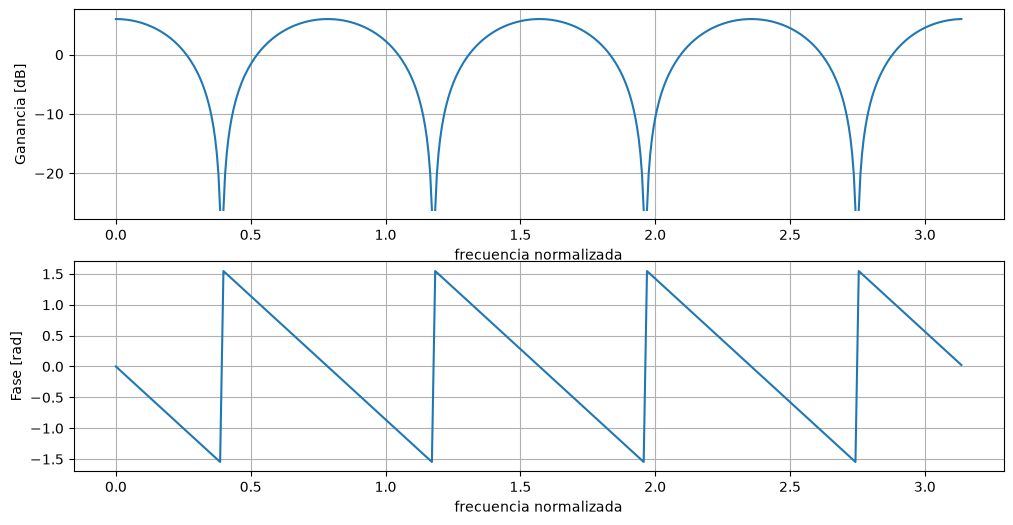

In [4]:

N = 8
num = [1] + [0]*(N-1) + [1]
den = [1]

w, h = sig.freqz(num, den)

#VISUALIZACION
myBodePlot(w,h)

peaks:  [0.0, 625.0, 1250.0, 1875.0]
nulls:  [312.5, 937.5, 1562.5, 2187.5000000000005]


C:\Users\brian\AppData\Local\Temp\ipykernel_22804\3656449624.py:8: RuntimeWarning: divide by zero encountered in log10
  hdb = 20*np.log10(np.abs(h))


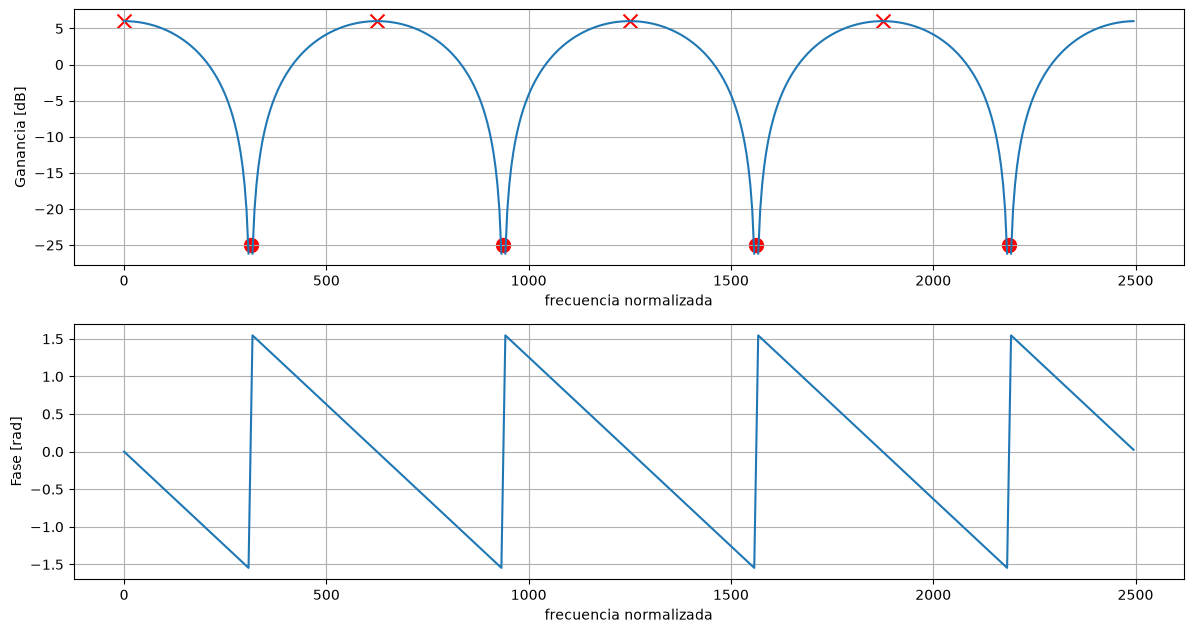

In [38]:

fs = 5e3
w, h = sig.freqz(num, den,fs=fs)
#los peaks y nulls normalizados a la frecuencia fs
peaks = [(fs/(2*np.pi))*k*np.pi/4 for k in range(4)]
nulls = [ (fs/(2*np.pi))*(2*k + 1)*np.pi/8 for k in range(4)]


hdb = 20*np.log10(np.abs(h))
peaks_mag = hdb[np.argmax(hdb)]
#nulls_mag = if hdb[np.argmin(hdb)] #me da infinito
nulls_mag = -25

print("peaks: ", peaks)
print("nulls: ", nulls)

plt.figure(figsize=(12, 6))
plt.subplot(2,1,1)
plt.plot(w, hdb)
plt.scatter(peaks, [peaks_mag]*len(peaks), marker='x', color='r', s=100)
plt.scatter(nulls, [nulls_mag]*len(nulls), marker='o', color='red', s=100)
plt.grid()
plt.xlabel(f"frecuencia normalizada")
plt.ylabel("Ganancia [dB]")
#plt.legend()
plt.tight_layout()

plt.subplot(2,1,2)
plt.plot(w, np.angle(h))
plt.grid()
plt.xlabel(f"frecuencia normalizada")
plt.ylabel("Fase [rad]")
#plt.legend()

plt.show()